In [2]:
import pandas as pd 
from sklearn.linear_model import LogisticRegression

In [12]:
# load the dataset
claimants = pd.read_csv('/Users/furkhanansari/Desktop/Data Science/DataSets/claimants.csv')
claimants.head()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038


In [13]:
# droping the casenum col as it is not required here
claimants.drop(['CASENUM'],inplace = True,axis =1)

In [15]:
claimants.shape


(1340, 6)

In [16]:
# removing the na values form the df
claimants = claimants.dropna()
claimants.shape

(1096, 6)

In [17]:
# Dviding the data into input and output variables 
X = claimants.iloc[:,1:]
Y = claimants.iloc[:,0]

In [20]:
# logistic regression and fit the model
classifier = LogisticRegression()
classifier.fit(X,Y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [21]:
# predict for X dataset
y_pred = classifier.predict(X)

In [24]:
y_pred

array([0, 1, 1, ..., 1, 0, 1], shape=(1096,))

In [22]:
y_pred_df = pd.DataFrame(
    {
        'actual' : Y,
        'Predicted_prob' : classifier.predict(X)
    }
)

In [23]:
y_pred_df

,actual,Predicted_prob
0,0,0
1,1,1
2,1,1
3,0,0
4,1,1
...,...,...
1334,1,1
1336,0,0
1337,1,1
1338,0,0


In [25]:
# confusion matrix for the model accuracy
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(Y,y_pred)
print(confusion_matrix)

[[381 197]
 [123 395]]


In [28]:
Accuracy = ((381+395)/(381+395+197+123))*100
print('Accuracy :',Accuracy)

Accuracy : 70.8029197080292


In [29]:
# Roc curves


Text(0, 0.5, 'True Negitive Rate')

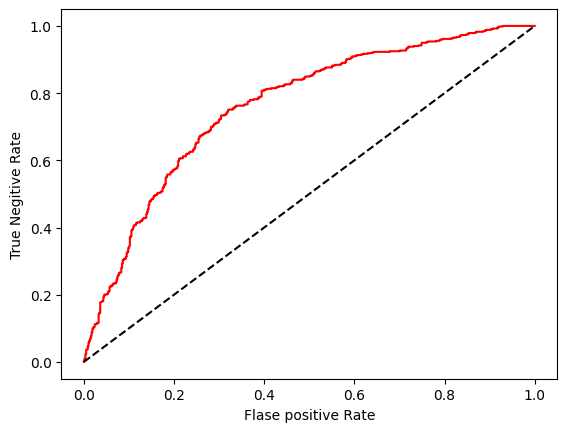

In [35]:
from sklearn.metrics import roc_curve 
from sklearn.metrics import roc_auc_score    #area under the curve 

fpr , tpr , thresholds = roc_curve(Y,classifier.predict_proba(X)[:,1])

auc = roc_auc_score(Y,y_pred)

import matplotlib.pyplot as plt
plt.plot(fpr,tpr,color = 'red',label = 'logit model ( area = %0.2f)' %auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('Flase positive Rate')
plt.ylabel('True Negitive Rate')

In [36]:
auc

0.7108589063606365

In [37]:
classifier.predict_proba(X)

array([[9.99996954e-01, 3.04592568e-06],
       [4.92832148e-01, 5.07167852e-01],
       [4.24835532e-01, 5.75164468e-01],
       ...,
       [2.60970584e-01, 7.39029416e-01],
       [7.14046063e-01, 2.85953937e-01],
       [3.19569059e-01, 6.80430941e-01]], shape=(1096, 2))